In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Colab에서 한글 그래프가 깨지는 것을 방지하기 위한 설정입니다.
# 설치가 필요한 경우 아래 첫 줄의 주석을 제거하고 실행하세요.
# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 나눔고딕 폰트 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_manager.fontManager.addfont(font_path)

# matplotlib 한글 폰트 설정
plt.rcParams["font.family"] = "NanumGothic"

# 마이너스(-) 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료: NanumGothic")



한글 폰트 설정 완료: NanumGothic


In [10]:
df = pd.read_csv('/content/drive/MyDrive/현대오토에버_파이썬/labeled_data.csv')

# 데이터 조작

## 컬럼추출 및 기초통계

In [11]:
df.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df.shape

(7996, 45)

In [13]:
df.describe()

,PART_FACT_SERIAL,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
count,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,7996.000000,...,7996.000000,7996.000000,7996.0,7996.0,7996.0,7996.0,7996.0,7996.0,7996.0,7996.0
mean,11.248749,8.242189,3.896309,16.209505,59.900902,7.064088,653.408195,0.330320,66.054484,544.244111,...,22.145260,23.522574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,5.005191,3.107724,1.284451,1.443720,0.885680,0.136595,10.165106,14.654889,5.418233,236.351404,...,1.177468,1.356586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,2.000000,1.050000,0.930000,10.920000,58.840000,5.160000,11.100000,0.000000,53.549999,4.630000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,9.000000,9.520000,4.400000,16.580000,59.520000,7.110000,653.429993,0.000000,68.250000,647.989990,...,21.400000,22.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,10.000000,9.560000,4.440000,16.799999,59.520000,7.120000,653.440002,0.000000,68.339996,647.989990,...,22.000000,23.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,13.000000,9.590000,4.470000,16.889999,59.560001,7.120000,653.450012,0.000000,68.489998,647.989990,...,22.900000,24.200001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,24.000000,16.309999,8.270000,21.120001,66.860001,7.180000,655.080017,655.309998,68.860001,883.700012,...,25.299999,27.799999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
list(df)

['_id',
 'TimeStamp',
 'PART_FACT_PLAN_DATE',
 'PART_FACT_SERIAL',
 'PART_NAME',
 'EQUIP_CD',
 'EQUIP_NAME',
 'PassOrFail',
 'Reason',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Switch_Over_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Barrel_Temperature_7',
 'Hopper_Temperature',
 'Mold_Temperature_1',
 'Mold_Temperature_2',
 'Mold_Temperature_3',
 'Mold_Temperature_4',
 'Mold_Temperature_5',
 'Mold_Temperature_6',
 'Mold_Temperature_7',
 'Mold_Temperature_8',
 'Mold_Temperature_9',
 'Mold_Temperature_10',
 'Mold_Temperature_11',
 'Mold_Temperature_12']

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7996 entries, 0 to 7995
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   _id                       7996 non-null   object 
 1   TimeStamp                 7996 non-null   object 
 2   PART_FACT_PLAN_DATE       7996 non-null   object 
 3   PART_FACT_SERIAL          7996 non-null   int64  
 4   PART_NAME                 7996 non-null   object 
 5   EQUIP_CD                  7996 non-null   object 
 6   EQUIP_NAME                7996 non-null   object 
 7   PassOrFail                7996 non-null   object 
 8   Reason                    71 non-null     object 
 9   Injection_Time            7996 non-null   float64
 10  Filling_Time              7996 non-null   float64
 11  Plasticizing_Time         7996 non-null   float64
 12  Cycle_Time                7996 non-null   float64
 13  Clamp_Close_Time          7996 non-null   float64
 14  Cushion_

In [16]:
df.isna().sum()

,0
_id,0
TimeStamp,0
PART_FACT_PLAN_DATE,0
PART_FACT_SERIAL,0
PART_NAME,0
EQUIP_CD,0
EQUIP_NAME,0
PassOrFail,0
Reason,7925
Injection_Time,0


In [17]:
df[~df['Reason'].isna()]

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
47,5f892e139c0189cc666f2c8c,2020-10-16 05:21:38,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,가스,9.58,...,25.000000,27.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80,5f8932439c0189cc666f62fe,2020-10-16 05:37:29,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,가스,9.60,...,25.200001,27.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95,5f8933ae9c0189cc666f75e1,2020-10-16 05:45:26,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,가스,9.59,...,25.200001,27.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,5f89344f9c0189cc666f7e7d,2020-10-16 05:47:24,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,가스,9.59,...,25.100000,27.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101,5f8934729c0189cc666f8064,2020-10-16 05:48:24,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,가스,9.58,...,25.200001,27.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5309,5f9775639c0189cc668f68fe,2020-10-27 01:04:41,2020-10-27 오전 12:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,초기허용불량,9.98,...,20.700001,22.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5310,5f97756d9c0189cc668f6a00,2020-10-27 01:04:41,2020-10-27 오전 12:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,초기허용불량,9.98,...,20.700001,22.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5311,5f9775729c0189cc668f6a4c,2020-10-27 01:05:41,2020-10-27 오전 12:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,초기허용불량,9.70,...,20.600000,21.900000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5312,5f97757a9c0189cc668f6aaa,2020-10-27 01:05:41,2020-10-27 오전 12:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,초기허용불량,9.70,...,20.600000,21.900000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 그룹을 지어서 컬럼추출

In [18]:
df['PassOrFail'].value_counts()

,count
PassOrFail,
Y,7925
N,71


In [19]:
df.groupby('PassOrFail')['Reason'].count()

,Reason
PassOrFail,
N,71
Y,0


## sort

In [20]:
df.sort_values('Injection_Time', ascending=True).head(5) # 오름차순

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
1279,5f8f87ee9c0189cc667919a5,2020-10-21 00:22:36,2020-10-21 오전 12:00:00,17,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,Y,NaN,1.05,...,21.5,22.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1280,5f8f87ee9c0189cc667919a8,2020-10-21 00:22:36,2020-10-21 오전 12:00:00,18,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,Y,NaN,1.05,...,21.5,22.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1281,5f8f87ef9c0189cc667919ab,2020-10-21 00:21:34,2020-10-21 오전 12:00:00,17,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,Y,NaN,1.05,...,21.5,22.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1282,5f8f87ef9c0189cc667919b5,2020-10-21 00:21:34,2020-10-21 오전 12:00:00,18,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,Y,NaN,1.05,...,21.5,22.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1611,5f911b209c0189cc667acf97,2020-10-22 05:39:05,2020-10-22 오전 12:00:00,10,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,Y,NaN,1.05,...,22.6,23.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df.sort_values('Injection_Time', ascending=False).head(5) # 내림차순

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
5859,5f99044e9c0189cc669e4fe0,2020-10-28 05:39:57,2020-10-28 오전 12:00:00,2,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,Y,NaN,16.309999,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3021,5f99044e9c0189cc669e4fe0,2020-10-28 05:39:57,2020-10-28 오전 12:00:00,2,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,Y,NaN,16.309999,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5299,5f9774fc9c0189cc668f6249,2020-10-27 00:56:21,2020-10-27 오전 12:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,초기허용불량,13.390000,...,20.4,21.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2461,5f9774fc9c0189cc668f6249,2020-10-27 00:56:21,2020-10-27 오전 12:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,N,초기허용불량,13.390000,...,20.4,21.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5300,5f9775049c0189cc668f62ae,2020-10-27 00:56:21,2020-10-27 오전 12:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,초기허용불량,13.390000,...,20.4,21.700001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 시각화

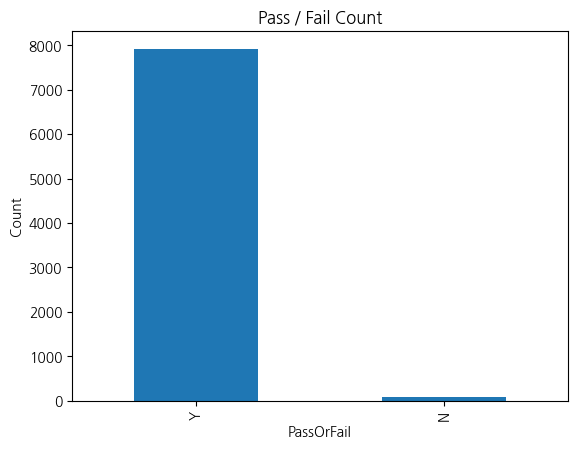

In [22]:
df['PassOrFail'].value_counts().plot(kind='bar')

plt.title('Pass / Fail Count')
plt.xlabel('PassOrFail')
plt.ylabel('Count')
plt.show()

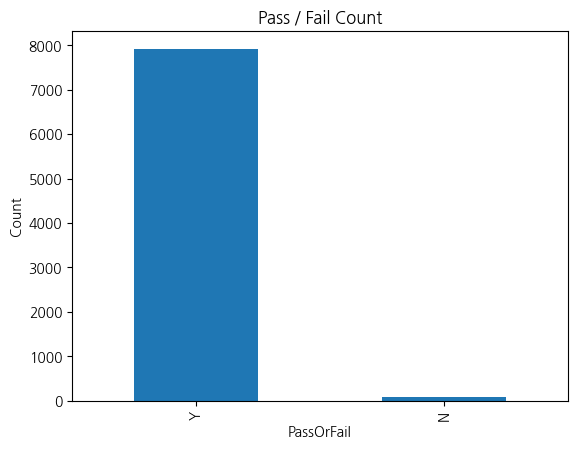

In [23]:
df['PassOrFail'].value_counts().plot(kind='bar')

plt.title('Pass / Fail Count')
plt.xlabel('PassOrFail')
plt.ylabel('Count')
plt.show()

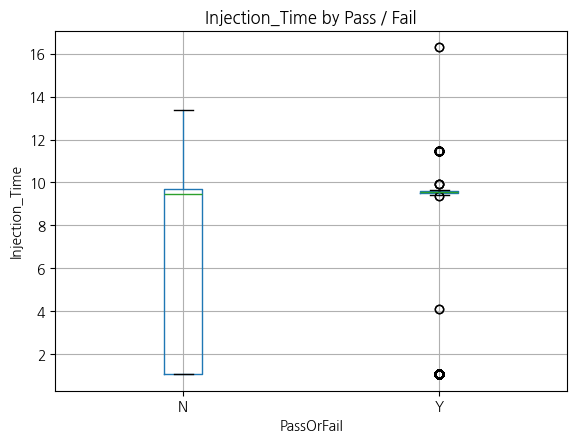

In [24]:
df.boxplot(column='Injection_Time', by='PassOrFail')

plt.title('Injection_Time by Pass / Fail')
plt.suptitle('')
plt.xlabel('PassOrFail')
plt.ylabel('Injection_Time')
plt.show()

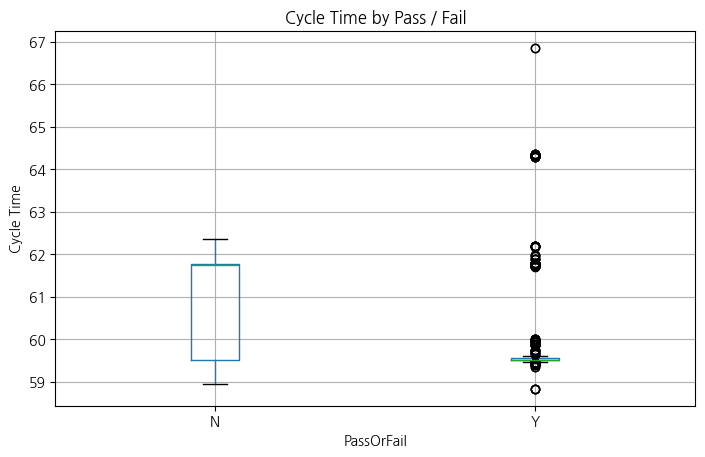

In [25]:
df.boxplot(
    column='Cycle_Time',
    by='PassOrFail',
    figsize=(8, 5)
)

plt.title('Cycle Time by Pass / Fail')
plt.suptitle('')
plt.xlabel('PassOrFail')
plt.ylabel('Cycle Time')
plt.show()

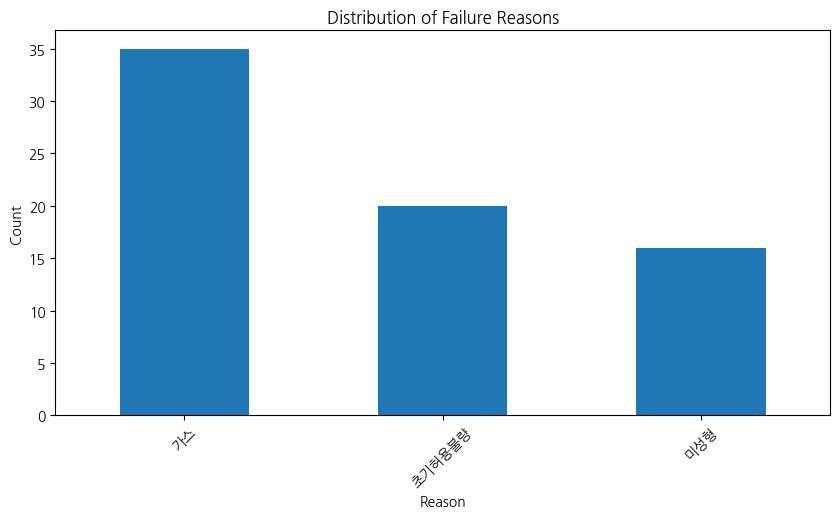

In [26]:
reason_counts = df['Reason'].value_counts()

reason_counts.plot(kind='bar', figsize=(10, 5))

plt.title('Distribution of Failure Reasons')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

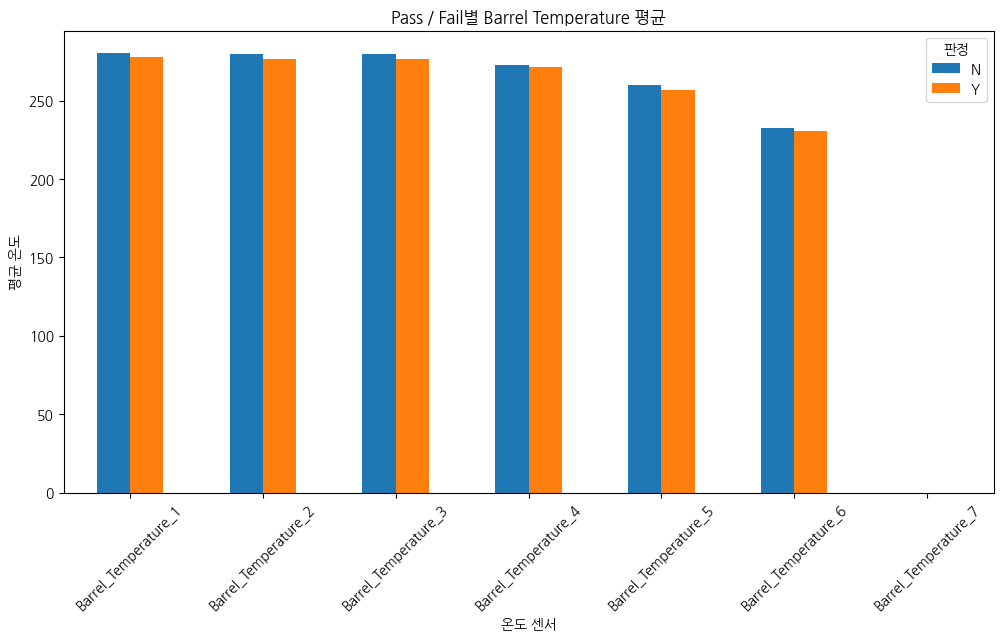

In [27]:
temp_cols = [
    'Barrel_Temperature_1',
    'Barrel_Temperature_2',
    'Barrel_Temperature_3',
    'Barrel_Temperature_4',
    'Barrel_Temperature_5',
    'Barrel_Temperature_6',
    'Barrel_Temperature_7'
]

temp_mean = df.groupby('PassOrFail')[temp_cols].mean().T

temp_mean.plot(kind='bar', figsize=(12, 6))

plt.title('Pass / Fail별 Barrel Temperature 평균')
plt.xlabel('온도 센서')
plt.ylabel('평균 온도')
plt.xticks(rotation=45)
plt.legend(title='판정')
plt.show()

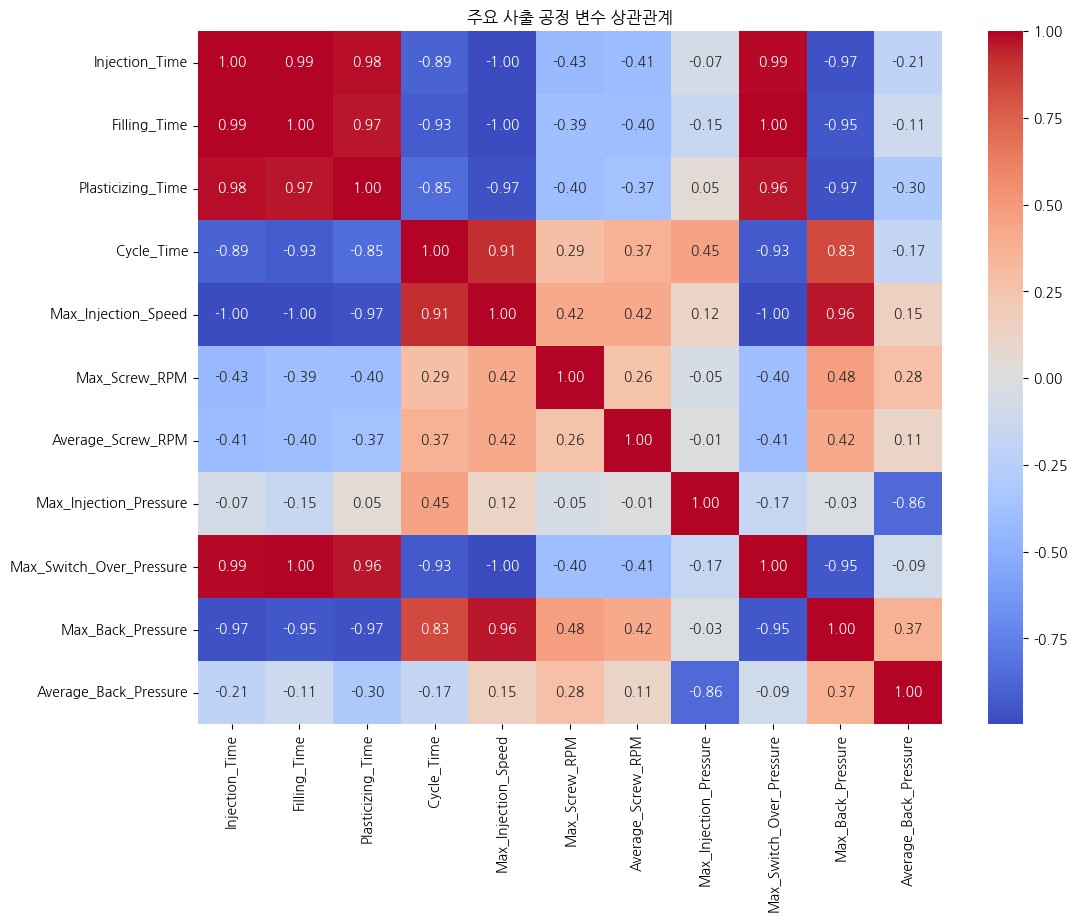

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'Injection_Time',
    'Filling_Time',
    'Plasticizing_Time',
    'Cycle_Time',
    'Max_Injection_Speed',
    'Max_Screw_RPM',
    'Average_Screw_RPM',
    'Max_Injection_Pressure',
    'Max_Switch_Over_Pressure',
    'Max_Back_Pressure',
    'Average_Back_Pressure'
]

corr = df[cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('주요 사출 공정 변수 상관관계')
plt.show()

# 전처리

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==========================================
# 1. 원본 데이터 복사
# ==========================================

df_cleaned = df.copy()


# ==========================================
# 2. 전체 값이 0인 컬럼 제거
# ==========================================

zero_cols = df_cleaned.columns[
    (df_cleaned == 0).all()
]

print("전체 값이 0인 컬럼:")
print(zero_cols)

df_cleaned = df_cleaned.drop(
    columns=zero_cols
)


# ==========================================
# 3. 사용하지 않을 컬럼 제거
# ==========================================

drop_cols = [
    '_id',
    'TimeStamp',
    'PART_FACT_PLAN_DATE',
    'PART_FACT_SERIAL',
    'PART_NAME',
    'EQUIP_CD',
    'Reason'
]

df_cleaned = df_cleaned.drop(
    columns=drop_cols,
    errors='ignore'
)


# ==========================================
# 4. X / y 분리
# ==========================================

X = df_cleaned.drop(
    columns=['PassOrFail']
)

y = df_cleaned['PassOrFail']


# Pass / Fail → 1 / 0
y = y.map({
    'Y': 1,
    'N': 0
})


# ==========================================
# 5. 카테고리 / 숫자형 컬럼 구분
# ==========================================

categorical_cols = [
    'EQUIP_NAME'
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]


print("\n카테고리 컬럼:")
print(categorical_cols)

print("\n숫자 컬럼:")
print(numeric_cols)


# ==========================================
# 6. Train / Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 7. 전처리
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[

        # 숫자형 → Standard Scaling
        (
            'num',
            StandardScaler(),
            numeric_cols
        ),

        # 카테고리형 → One-Hot Encoding
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)


X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


print("\n전처리 후 변수 개수:")
print(X_train_processed.shape[1])

전체 값이 0인 컬럼:
Index(['Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
       'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
       'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
       'Mold_Temperature_12'],
      dtype='object')

카테고리 컬럼:
['EQUIP_NAME']

숫자 컬럼:
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

전처리 후 변수 개수:
29


# 모델링

## 로지스틱, 결정트리, 랜덤포레스트, 그래디언트 부스팅, SVM, KNN

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ==========================================
# 1. 원본 데이터 복사
# ==========================================

df_cleaned = df.copy()


# ==========================================
# 2. 전체 값이 0인 컬럼 제거
# ==========================================

zero_cols = df_cleaned.columns[
    (df_cleaned == 0).all()
]

print("제거할 0 컬럼:")
print(zero_cols)

df_cleaned = df_cleaned.drop(
    columns=zero_cols
)


# ==========================================
# 3. 사용하지 않을 컬럼 제거
# ==========================================

drop_cols = [
    '_id',
    'TimeStamp',
    'PART_FACT_PLAN_DATE',
    'PART_FACT_SERIAL',
    'PART_NAME',
    'EQUIP_CD',
    'Reason'
]

df_cleaned = df_cleaned.drop(
    columns=drop_cols,
    errors='ignore'
)


# ==========================================
# 4. X / y 분리
# ==========================================

X = df_cleaned.drop(
    columns=['PassOrFail']
)

y = df_cleaned['PassOrFail'].map({
    'Y': 0,
    'N': 1
})


# ==========================================
# 5. 컬럼 구분
# ==========================================

categorical_cols = [
    'EQUIP_NAME'
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]


# ==========================================
# 6. Train / Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 7. 전처리
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


print("\n전처리 완료")
print("변수 개수:", X_train_processed.shape[1])


# ==========================================
# 8. 모델 정의
# ==========================================

models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=1000
        ),

    'Decision Tree':
        DecisionTreeClassifier(
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    'Gradient Boosting':
        GradientBoostingClassifier(
            random_state=42
        ),

    'SVM':
        SVC(
            probability=True,
            random_state=42
        ),

    'KNN':
        KNeighborsClassifier(
            n_neighbors=5
        )
}



제거할 0 컬럼:
Index(['Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
       'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
       'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
       'Mold_Temperature_12'],
      dtype='object')

전처리 완료
변수 개수: 29


In [31]:
# ==========================================
# 9. 모델 학습 및 평가
# ==========================================

results = []
confusion_matrices = {}

for name, model in models.items():

    print(f"\n{name} 학습 중...")

    # 모델 학습
    model.fit(
        X_train_processed,
        y_train
    )

    # 예측
    y_pred = model.predict(
        X_test_processed
    )

    # 성능 저장
    results.append({

        'Model': name,

        'Accuracy':
            accuracy_score(
                y_test,
                y_pred
            ),

        'Precision':
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        'Recall':
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        'F1':
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            )
    })

    # 혼동행렬 저장
    confusion_matrices[name] = confusion_matrix(
        y_test,
        y_pred
    )


# ==========================================
# 10. 결과 DataFrame
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1',
    ascending=False
).reset_index(drop=True)


print("\n==========================================")
print("모델 성능 비교")
print("==========================================")

display(results_df)


Logistic Regression 학습 중...

Decision Tree 학습 중...

Random Forest 학습 중...

Gradient Boosting 학습 중...

SVM 학습 중...

KNN 학습 중...

모델 성능 비교


,Model,Accuracy,Precision,Recall,F1
0,Gradient Boosting,0.990625,0.454545,0.357143,0.400000
1,Decision Tree,0.989375,0.384615,0.357143,0.370370
2,Random Forest,0.989375,0.384615,0.357143,0.370370
3,Logistic Regression,0.993125,1.000000,0.214286,0.352941
4,SVM,0.993125,1.000000,0.214286,0.352941
5,KNN,0.993125,1.000000,0.214286,0.352941


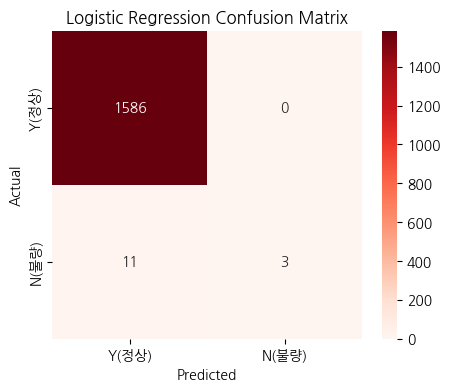

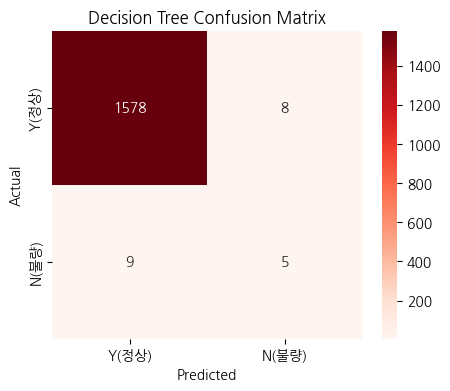

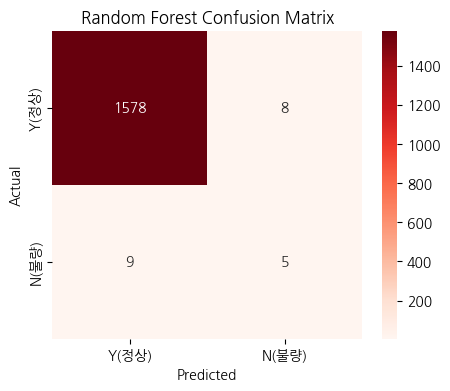

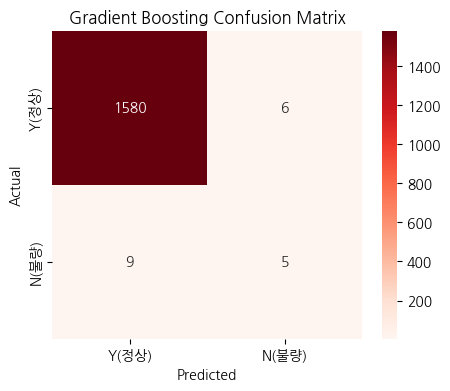

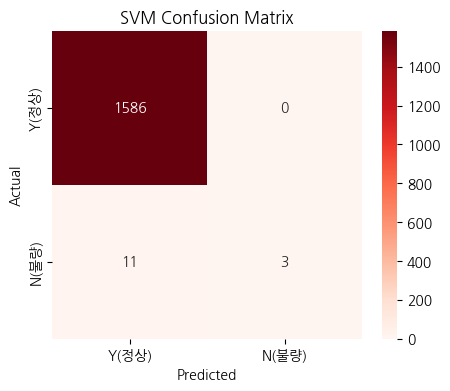

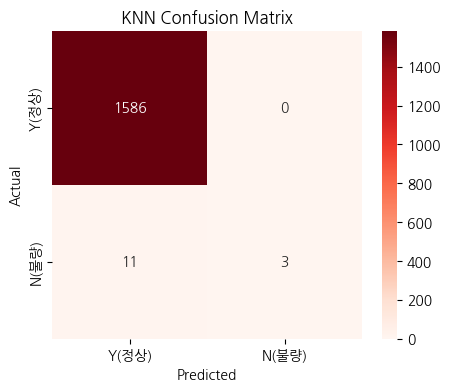

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, cm in confusion_matrices.items():

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Reds',
        xticklabels=['Y(정상)', 'N(불량)'],
        yticklabels=['Y(정상)', 'N(불량)']
    )

    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

## 그래디언트, 랜덤포레스트

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

# ==========================================
# 일반 Train / Test
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 모델
# ==========================================

models = {

    'Random Forest':
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        ),

    'Gradient Boosting':
        GradientBoostingClassifier(
            random_state=42
        )
}


# ==========================================
# 결과 저장
# ==========================================

general_results = []
general_cm = {}


# ==========================================
# 모델 학습
# ==========================================

for name, model in models.items():

    # 전처리 + 모델 Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])


    # Gradient Boosting은 class_weight가 없기 때문에
    # sample_weight 사용
    if name == 'Gradient Boosting':

        sample_weight = np.where(
            y_train == 1,
            len(y_train) / (2 * sum(y_train == 1)),
            len(y_train) / (2 * sum(y_train == 0))
        )

        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weight
        )

    else:

        pipeline.fit(
            X_train,
            y_train
        )


    # 확률 예측
    y_prob = pipeline.predict_proba(
        X_test
    )[:, 1]

    # 클래스 예측
    y_pred = (
        y_prob >= 0.5
    ).astype(int)


    # 성능
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )


    # 결과 저장
    general_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc
    })


    # 혼동행렬 저장
    general_cm[name] = confusion_matrix(
        y_test,
        y_pred
    )


# ==========================================
# 결과 DataFrame
# ==========================================

general_results_df = pd.DataFrame(
    general_results
)

display(
    general_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.9894,0.3846,0.3571,0.3704,0.8443
1,Gradient Boosting,0.9688,0.1400,0.5000,0.2188,0.9330


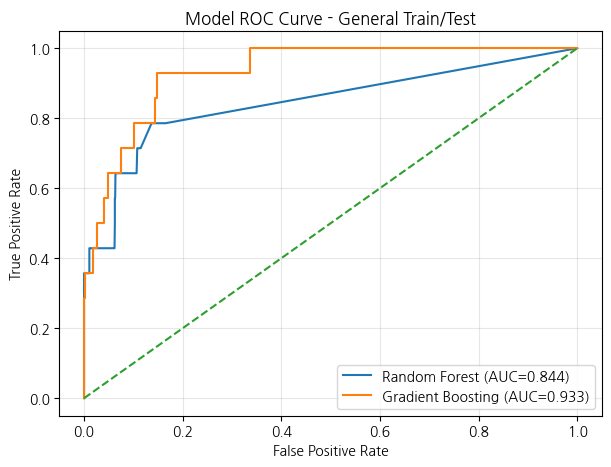

In [34]:
# ==========================================
# 일반 Train/Test ROC Curve
# ==========================================

plt.figure(figsize=(7, 5))

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    if name == 'Gradient Boosting':

        sample_weight = np.where(
            y_train == 1,
            len(y_train) / (2 * sum(y_train == 1)),
            len(y_train) / (2 * sum(y_train == 0))
        )

        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weight
        )

    else:

        pipeline.fit(
            X_train,
            y_train
        )

    y_prob = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc:.3f})'
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model ROC Curve - General Train/Test')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

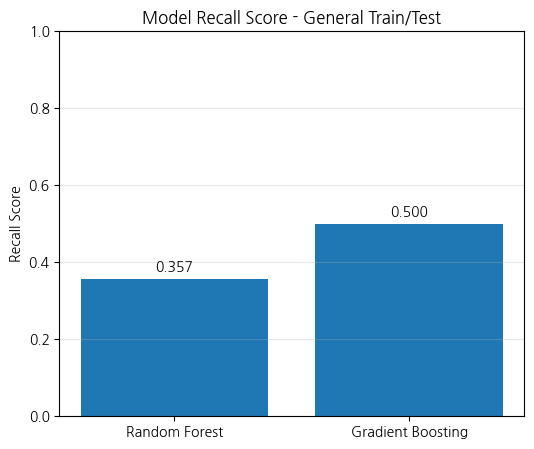

In [35]:
# ==========================================
# 일반 Train/Test F1 Score
# ==========================================

plt.figure(figsize=(6, 5))

names = general_results_df['Model']
Recall_values = general_results_df['Recall']

bars = plt.bar(
    names,
    Recall_values
)

plt.ylabel('Recall Score')
plt.title('Model Recall Score - General Train/Test')
plt.ylim(0, 1)

for bar, value in zip(bars, Recall_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.3f}',
        ha='center'
    )

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

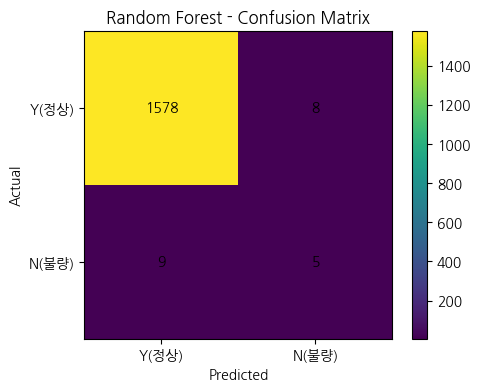

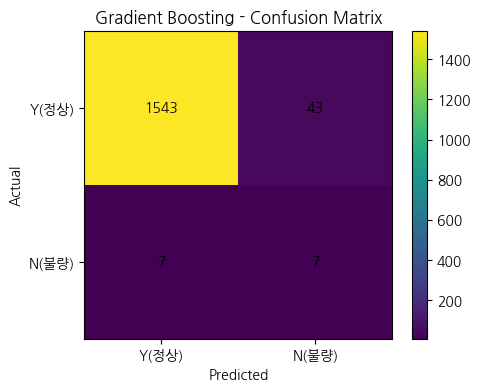

In [36]:
# ==========================================
# 일반 Train/Test Confusion Matrix
# ==========================================

for name, cm in general_cm.items():

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(
        f'{name} - Confusion Matrix'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.xticks(
        [0, 1],
        ['Y(정상)', 'N(불량)']
    )

    plt.yticks(
        [0, 1],
        ['Y(정상)', 'N(불량)']
    )

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    plt.colorbar()
    plt.show()

## k-fold + 그래디언트, 랜덤포레스트

In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import numpy as np
import pandas as pd


# ==========================================
# 5-Fold Cross Validation
# ==========================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# 결과 저장
kfold_results = []

# 모델별 OOF 결과 저장
oof_results = {}


# ==========================================
# 모델별 K-Fold
# ==========================================

for name, model in models.items():

    fold_recall = []
    fold_f1 = []
    fold_auc = []

    oof_y = []
    oof_prob = []


    for fold, (train_idx, test_idx) in enumerate(
        skf.split(X, y),
        1
    ):

        X_train_fold = X.iloc[train_idx]
        X_test_fold = X.iloc[test_idx]

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]


        # --------------------------------------
        # Fold마다 새로운 Pipeline
        # --------------------------------------

        pipeline = Pipeline([
            (
                'preprocessor',
                ColumnTransformer(
                    transformers=[
                        (
                            'num',
                            StandardScaler(),
                            numeric_cols
                        ),
                        (
                            'cat',
                            OneHotEncoder(
                                handle_unknown='ignore',
                                sparse_output=False
                            ),
                            categorical_cols
                        )
                    ]
                )
            ),
            (
                'model',
                model.__class__(
                    **model.get_params()
                )
            )
        ])


        # --------------------------------------
        # Gradient Boosting
        # 불량(1)에 가중치 부여
        # --------------------------------------

        if name == 'Gradient Boosting':

            sample_weight = np.where(
                y_train_fold == 1,

                len(y_train_fold) /
                (2 * sum(y_train_fold == 1)),

                len(y_train_fold) /
                (2 * sum(y_train_fold == 0))
            )

            pipeline.fit(
                X_train_fold,
                y_train_fold,
                model__sample_weight=sample_weight
            )

        else:

            pipeline.fit(
                X_train_fold,
                y_train_fold
            )


        # --------------------------------------
        # 예측
        # --------------------------------------

        prob = pipeline.predict_proba(
            X_test_fold
        )[:, 1]

        pred = (
            prob >= 0.5
        ).astype(int)


        # --------------------------------------
        # Fold 성능
        # --------------------------------------

        # 불량 Recall
        fold_recall.append(
            recall_score(
                y_test_fold,
                pred,
                zero_division=0
            )
        )

        # F1
        fold_f1.append(
            f1_score(
                y_test_fold,
                pred,
                zero_division=0
            )
        )

        # AUC
        fold_auc.append(
            roc_auc_score(
                y_test_fold,
                prob
            )
        )


        # --------------------------------------
        # OOF 저장
        # --------------------------------------

        oof_y.extend(
            y_test_fold
        )

        oof_prob.extend(
            prob
        )


    # ==========================================
    # OOF 전체 성능
    # ==========================================

    oof_y = np.array(oof_y)
    oof_prob = np.array(oof_prob)

    oof_pred = (
        oof_prob >= 0.5
    ).astype(int)


    # Recall
    recall = recall_score(
        oof_y,
        oof_pred,
        zero_division=0
    )

    # F1
    f1 = f1_score(
        oof_y,
        oof_pred,
        zero_division=0
    )

    # AUC
    auc = roc_auc_score(
        oof_y,
        oof_prob
    )


    # ==========================================
    # 결과 저장
    # ==========================================

    kfold_results.append({

        'Model': name,

        # OOF 전체 성능
        'Recall': recall,
        'F1': f1,
        'AUC': auc,

        # Fold 평균
        'Recall Mean':
            np.mean(fold_recall),

        'Recall Std':
            np.std(fold_recall),

        'F1 Mean':
            np.mean(fold_f1),

        'F1 Std':
            np.std(fold_f1),

        'AUC Mean':
            np.mean(fold_auc),

        'AUC Std':
            np.std(fold_auc)
    })


    # ==========================================
    # OOF 결과 저장
    # ==========================================

    oof_results[name] = {

        'y': oof_y,

        'prob': oof_prob,

        'pred': oof_pred
    }


# ==========================================
# K-Fold 결과 DataFrame
# ==========================================

kfold_results_df = pd.DataFrame(
    kfold_results
)


# Recall 기준으로 정렬
kfold_results_df = kfold_results_df.sort_values(
    'Recall',
    ascending=False
)


display(
    kfold_results_df.round(4)
)

,Model,Recall,F1,AUC,Recall Mean,Recall Std,F1 Mean,F1 Std,AUC Mean,AUC Std
1,Gradient Boosting,0.5211,0.2056,0.9226,0.5229,0.1444,0.2057,0.0342,0.9266,0.0416
0,Random Forest,0.3944,0.4118,0.9232,0.3971,0.1508,0.4010,0.1002,0.9229,0.0299


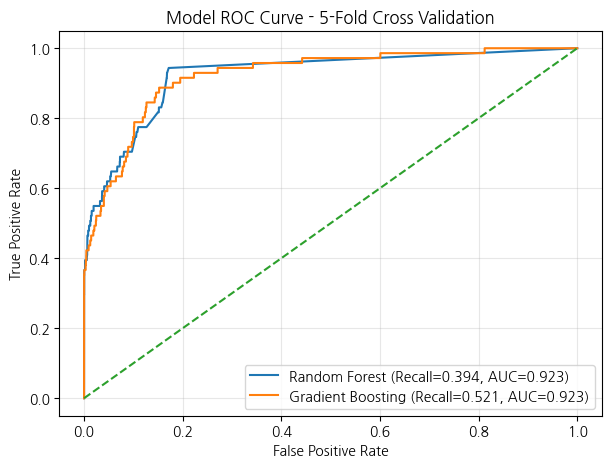

In [38]:
# ==========================================
# 5-Fold Cross Validation ROC Curve
# ==========================================

plt.figure(figsize=(7, 5))


for name, result in oof_results.items():

    y_true = result['y']
    y_prob = result['prob']


    # --------------------------------------
    # ROC / AUC
    # --------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )


    # --------------------------------------
    # Recall
    # --------------------------------------

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )


    # --------------------------------------
    # ROC Curve
    # --------------------------------------

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (Recall={recall:.3f}, AUC={auc:.3f})'
    )


# ==========================================
# 기준선
# ==========================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)


# ==========================================
# 그래프 설정
# ==========================================

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'Model ROC Curve - 5-Fold Cross Validation'
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

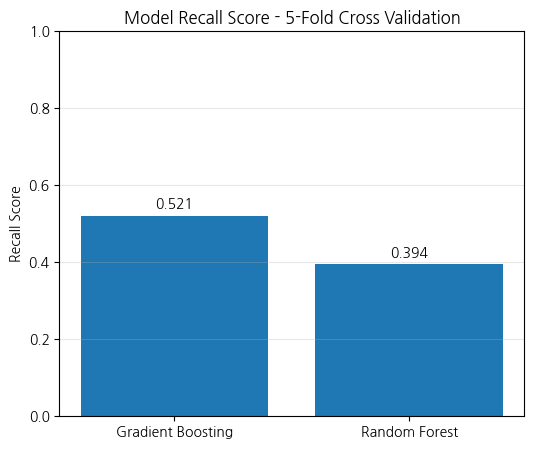

In [39]:
# ==========================================
# 5-Fold Cross Validation Recall Score
# ==========================================

plt.figure(figsize=(6, 5))

names = kfold_results_df['Model']
recall_values = kfold_results_df['Recall']

bars = plt.bar(
    names,
    recall_values
)

plt.ylabel('Recall Score')
plt.title('Model Recall Score - 5-Fold Cross Validation')
plt.ylim(0, 1)


# 값 표시
for bar, value in zip(bars, recall_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.3f}',
        ha='center'
    )


plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

## ML 개선(그리드 서치)

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 전처리 및 모델 셀렉션
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 모델 및 평가 지표
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# [중요] SMOTE 누수 방지를 위한 imblearn 파이프라인
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. 원본 데이터 복사 및 불필요 컬럼 제거
# ==========================================
df_cleaned = df.copy()

# 전체 값이 0인 컬럼 제거
zero_cols = df_cleaned.columns[(df_cleaned == 0).all()]
print("전체 값이 0인 컬럼:", zero_cols.tolist())
df_cleaned = df_cleaned.drop(columns=zero_cols)

# 사용하지 않을 컬럼 제거
drop_cols = [
    '_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
    'PART_NAME', 'EQUIP_CD', 'Reason'
]
df_cleaned = df_cleaned.drop(columns=drop_cols, errors='ignore')

# ==========================================
# 2. X / y 분리 및 타겟 매핑
# ==========================================
X = df_cleaned.drop(columns=['PassOrFail'])
y = df_cleaned['PassOrFail']

# Pass / Fail → 1 / 0 (통상 불량 탐지가 목적일 경우, 타겟(1)이 불량이 되도록 맵핑 확인 필요)
y = df_cleaned['PassOrFail'].map({'N': 1, 'Y': 0})

# ==========================================
# 3. 카테고리 / 숫자형 컬럼 구분
# ==========================================
categorical_cols = ['EQUIP_NAME']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# ==========================================
# 4. Train / Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\n학습 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}")

# ==========================================
# 5. 전처리 객체 정의 (변환은 파이프라인 내부에서 수행)
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)



전체 값이 0인 컬럼: ['Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12']

학습 데이터 크기: (6396, 27), 테스트 데이터 크기: (1600, 27)


In [45]:
# ==========================================
# 6. 모델 및 하이퍼파라미터 세팅
# ==========================================
search_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RF_Original': RandomForestClassifier(class_weight='balanced', random_state=42),
    'RF_SMOTE': RandomForestClassifier(random_state=42),
    'GB_Original': GradientBoostingClassifier(random_state=42),
    'GB_SMOTE': GradientBoostingClassifier(random_state=42)
}

param_grids = {
    'RF_Original': {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [1, 5]},
    'RF_SMOTE':    {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [1, 5]},
    'GB_Original': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5]},
    'GB_SMOTE':    {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5]}
}

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

# ==========================================
# 7. Grid Search 실행 (X_train, y_train 기준)
# ==========================================
best_params = {}
best_models = {}
grid_results = {}

for name in models.keys():
    print('=' * 60)
    print(f'[{name}] 최적 파라미터 탐색 중...')

    # SMOTE 적용 여부에 따른 파이프라인 구성
    if 'SMOTE' in name:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', models[name])
        ])
    else:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', models[name])
        ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring=scoring,
        refit='recall',  # 미탐 방지(Recall) 최우선
        cv=search_cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )

    # GB 원본 모델에만 sample_weight 적용
    if name == 'GB_Original':
        # 주의: 여기서는 훈련 데이터(y_train) 기준으로 가중치를 계산해야 합니다.
        sample_weight = np.where(y_train == 1, len(y_train)/(2*sum(y_train==1)), len(y_train)/(2*sum(y_train==0)))
        grid_search.fit(X_train, y_train, model__sample_weight=sample_weight)
    else:
        grid_search.fit(X_train, y_train)

    best_params[name] = grid_search.best_params_
    best_models[name] = grid_search.best_estimator_
    grid_results[name] = pd.DataFrame(grid_search.cv_results_)

# ==========================================
# 8. 모델별 최고 성능 비교 (Train CV 기준)
# ==========================================
best_performance = []
for name in grid_results:
    results = grid_results[name]
    best_idx = results['rank_test_recall'].idxmin()
    best_performance.append({
        'Model': name,
        'Recall (미탐방지)': results.loc[best_idx, 'mean_test_recall'],
        'Precision (오탐방지)': results.loc[best_idx, 'mean_test_precision'],
        'F1 Score': results.loc[best_idx, 'mean_test_f1']
    })

best_perf_df = pd.DataFrame(best_performance).sort_values('Recall (미탐방지)', ascending=False).reset_index(drop=True)
print("\n🏆 [교차검증(CV) 기준 모델 성능 비교 - Recall 최우선]")
display(best_perf_df.round(4))


[RF_Original] 최적 파라미터 탐색 중...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[RF_SMOTE] 최적 파라미터 탐색 중...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[GB_Original] 최적 파라미터 탐색 중...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[GB_SMOTE] 최적 파라미터 탐색 중...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

🏆 [교차검증(CV) 기준 모델 성능 비교 - Recall 최우선]


,Model,Recall (미탐방지),Precision (오탐방지),F1 Score
0,GB_Original,0.6985,0.1051,0.1820
1,RF_SMOTE,0.5894,0.0735,0.1301
2,RF_Original,0.5712,0.0889,0.1532
3,GB_SMOTE,0.4652,0.1077,0.1740


## ML 개선(스레스홀드 탐색)

In [54]:
# ==========================================
# 9. 최종 Test Data 대상 Threshold(임계값) 튜닝
# ==========================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# (성능표에서 1등으로 나온 모델 선택)
top_model_name = best_perf_df.iloc[0]['Model']
final_model = best_models[top_model_name]

print(f"\n🎯 [최종 임계값 튜닝 - 선택된 모델: {top_model_name}]")

# X_test 예측 확률 추출
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# ROC-AUC는 확률값 기준이므로 임계값 변화와 무관하게 고정됩니다.
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"▶ 고정 ROC-AUC Score : {auc_score:.4f}\n")

thresholds = [0.1, 0.2, 0.225, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# 출력 헤더 정리
print(f"{'Threshold':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} | {'Confusion Matrix (TN, FP, FN, TP)'}")
print("-" * 105)

for t in thresholds:
    # 임계값 적용
    y_pred_custom = (y_pred_proba >= t).astype(int)

    # 평가 지표 계산
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom, zero_division=0)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    # 혼동 행렬 (실제 건수 확인용)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    # 결과 출력
    print(f"{t:<10.2f} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | [정상맞춤:{tn} | 오탐(FP):{fp} | 미탐(FN):{fn} | 불량맞춤:{tp}]")


🎯 [최종 임계값 튜닝 - 선택된 모델: GB_Original]
▶ 고정 ROC-AUC Score : 0.9530

Threshold  | Accuracy   | Precision  | Recall     | F1 Score   | Confusion Matrix (TN, FP, FN, TP)
---------------------------------------------------------------------------------------------------------
0.10       | 0.8106     | 0.0442     | 1.0000     | 0.0846     | [정상맞춤:1283 | 오탐(FP):303 | 미탐(FN):0 | 불량맞춤:14]
0.20       | 0.8719     | 0.0639     | 1.0000     | 0.1202     | [정상맞춤:1381 | 오탐(FP):205 | 미탐(FN):0 | 불량맞춤:14]
0.23       | 0.8800     | 0.0680     | 1.0000     | 0.1273     | [정상맞춤:1394 | 오탐(FP):192 | 미탐(FN):0 | 불량맞춤:14]
0.30       | 0.8962     | 0.0632     | 0.7857     | 0.1170     | [정상맞춤:1423 | 오탐(FP):163 | 미탐(FN):3 | 불량맞춤:11]
0.40       | 0.9250     | 0.0726     | 0.6429     | 0.1304     | [정상맞춤:1471 | 오탐(FP):115 | 미탐(FN):5 | 불량맞춤:9]
0.50       | 0.9487     | 0.1047     | 0.6429     | 0.1800     | [정상맞춤:1509 | 오탐(FP):77 | 미탐(FN):5 | 불량맞춤:9]
0.60       | 0.9581     | 0.1045     | 0.5000     | 0.1728     | [